In [30]:
from src.layers.transformer.ATAT import LightCurveTransformer
from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY,ZTF_TAXONOMY

import pandas as pd

In [55]:
colors = [
    '#ffacfa',# agn
    '#D747CF', #qso 1
    "#189a95", # EA 2

    "#bb3e00", #yso 3
    '#70df00',  # snia 4
    "#FE0912", # cvnova 5

    '#009cff',# 6 rrlc  tt
    "#0004ffff",  # 7 rscvn
    "#cd0066",#'#96034A', #blacar 8

    '#2F8B04', # snii 9
    '#7a71f8', # ebew 10
    "#3b3ee7ff", #lpv 11

    "#41708f", # cep 12
    '#00e3ff', # rrlab 13
    '#1FA9FF', # periodic other 14
     '#00e3ff', #dsct 15
    "#458a00", # snibc 16
    "#1E5A2E", # slsn 17
    "#ff8000", # tde 18

    '#FFC71F', # sniib 19
    '#FFEC1F', # sniin 20
    "#FFFFFF", # microlensing 21
    ]

colors_hier = [
    #,'#554FCF
    #'#FBAC23', #agn 0
    '#fd31ee',# agn
    '#fd31ee', #qso 1
    '#00e3ff', # EA 2

    '#fd31ee', #yso 3
    '#1bda00',  # snia 4
    '#fd31ee', # cvnova 5
    '#00e3ff',# 6 rrlc  tt
    '#00e3ff',  # 7 rscvn
    '#fd31ee',#'#96034A', #blacar 8
    '#1bda00', # snii 9
    '#00e3ff', # ebew 10
    '#00e3ff', #lpv 11

    '#00e3ff', # cep 12
    '#00e3ff', # rrlab 13
    '#00e3ff', # periodic other 14
    '#60fff3', #dsct 15
    '#1bda00', # snibc 16
    '#1bda00', # slsn 17
    '#1bda00', # tde 18
    '#1bda00', # sniib 19
    '#1bda00', # sniin 20
    '#1bda00', # microlensing 21
    ]

In [56]:
PATH = '/home/magdalena/rpos/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/PRETRAIN/LC/20260314_ema_optim_change_1491_1e3/'
#FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"
FP_DATASET ='/home/magdalena/Desktop/sambashare/H5_files/BY_PARTITION/200_FF.h5'
#FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"
DEVICE = 'cuda:0'
TAXONOMY = ZTF_TAXONOMY

In [86]:
from src.exploringtools.ExplorePretraining import ExplorePretraining
from src.exploringtools.InitDataloader import InitDataLoader



test = ExplorePretraining(path_to_config_yaml=PATH,
                    model= LightCurveTransformer,
                    arg_key='lc')
od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'transformer_tab', 'classifier'],rename_keys = ('model.',''), checkpoint_name='pretrain_ckpt')
test.load_backbone_weights(od)

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_validation_dataset()


Using checkpoint 6808.ckpt
     - Loaded backbone weights


In [85]:
X_val, y_val =test.predict(dl.validation_dataset, DEVICE)



device set to cuda:0


  0%|          | 0/382 [00:00<?, ?it/s]

100%|██████████| 382/382 [00:07<00:00, 53.92it/s]


In [87]:
target = y_val
from sklearn.discriminant_analysis import StandardScaler
import umap
import umap.plot
scaler = StandardScaler()
import bokeh
bokeh.io.output_notebook()

umap_args = {'min_dist':0.5}
umap_obj = umap.UMAP(**umap_args)
#mapper = umap_obj.fit(scaler.fit_transform(X_val))
mapper = umap_obj.fit(X_val)
hover_data = pd.DataFrame({'index':range(len(X_val)),
                            'label':y_val,
                            })

hover_data['class'] = hover_data.label.map({value:key for key,value in TAXONOMY().items()})

Loading BokehJS ...

<Axes: >

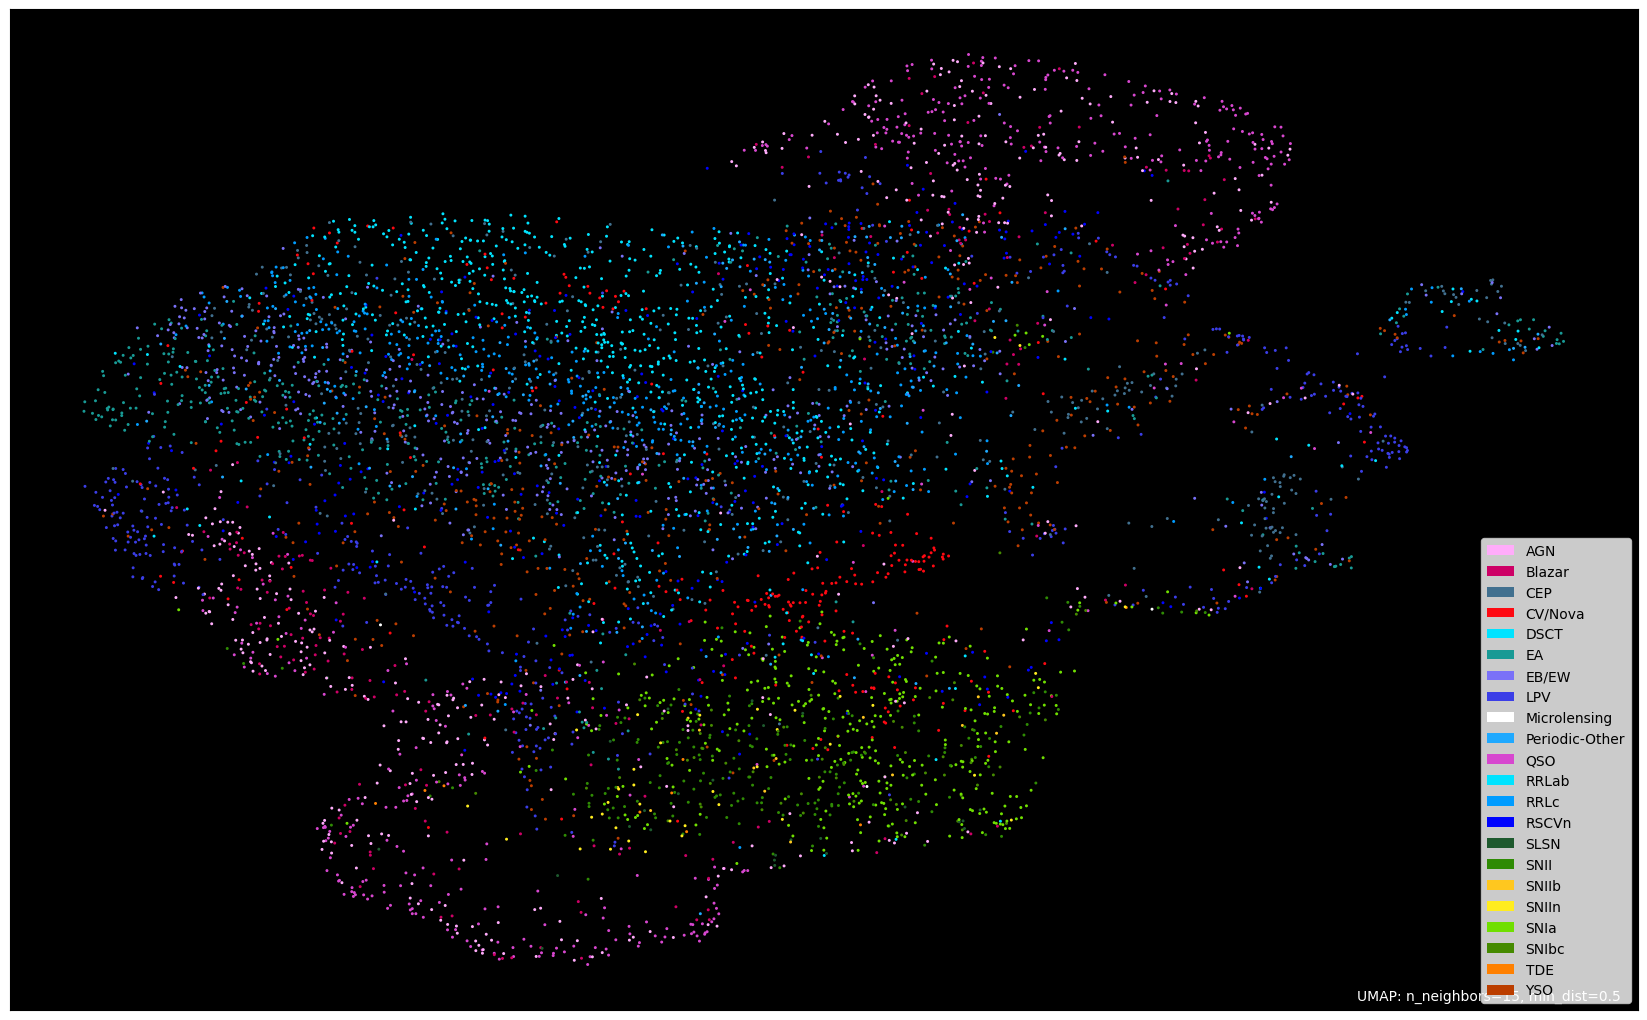

In [88]:
import numpy as np

colors = [
    '#ffacfa',# agn
     "#cd0066",#'#96034A', #blacar 8
      "#41708f", # cep 12
      "#FE0912", # cvnova 5
        '#00e3ff', #dsct 15
    "#189a95", # EA 2
 '#7a71f8', # ebew 10
   "#3b3ee7ff", #lpv 11
     "#FFFFFF", # microlensing 21
      '#1FA9FF', # periodic other 14
       '#D747CF', #qso 1
  '#00e3ff', # rrlab 13
    '#009cff',# 6 rrlc  tt
    "#0004ffff",  # 7 rscvn
      "#1E5A2E", # slsn 17
       '#2F8B04', # snii 9
     '#FFC71F', # sniib 19
    '#FFEC1F', # sniin 20
     '#70df00',  # snia 4
     "#458a00", # snibc 16
       "#ff8000", # tde 18
     "#bb3e00", #yso 3
    ]
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (21,13))
ax = fig.add_subplot(111)
#plt.title('UMAP Dimensionality Reduction Before Pretraining the Embedding Space')
umap.plot.points(mapper, labels = np.array([{value:key for key, value in ZTF_TAXONOMY().items()}[i] for i in target.astype(int)]), height = 1080, width = 1920, background = 'black', color_key = colors, ax = ax)

<Axes: title={'center': 'UMAP Dimensionality Reduction for the Pretrained Embedding Space by Hierarchy Class'}>

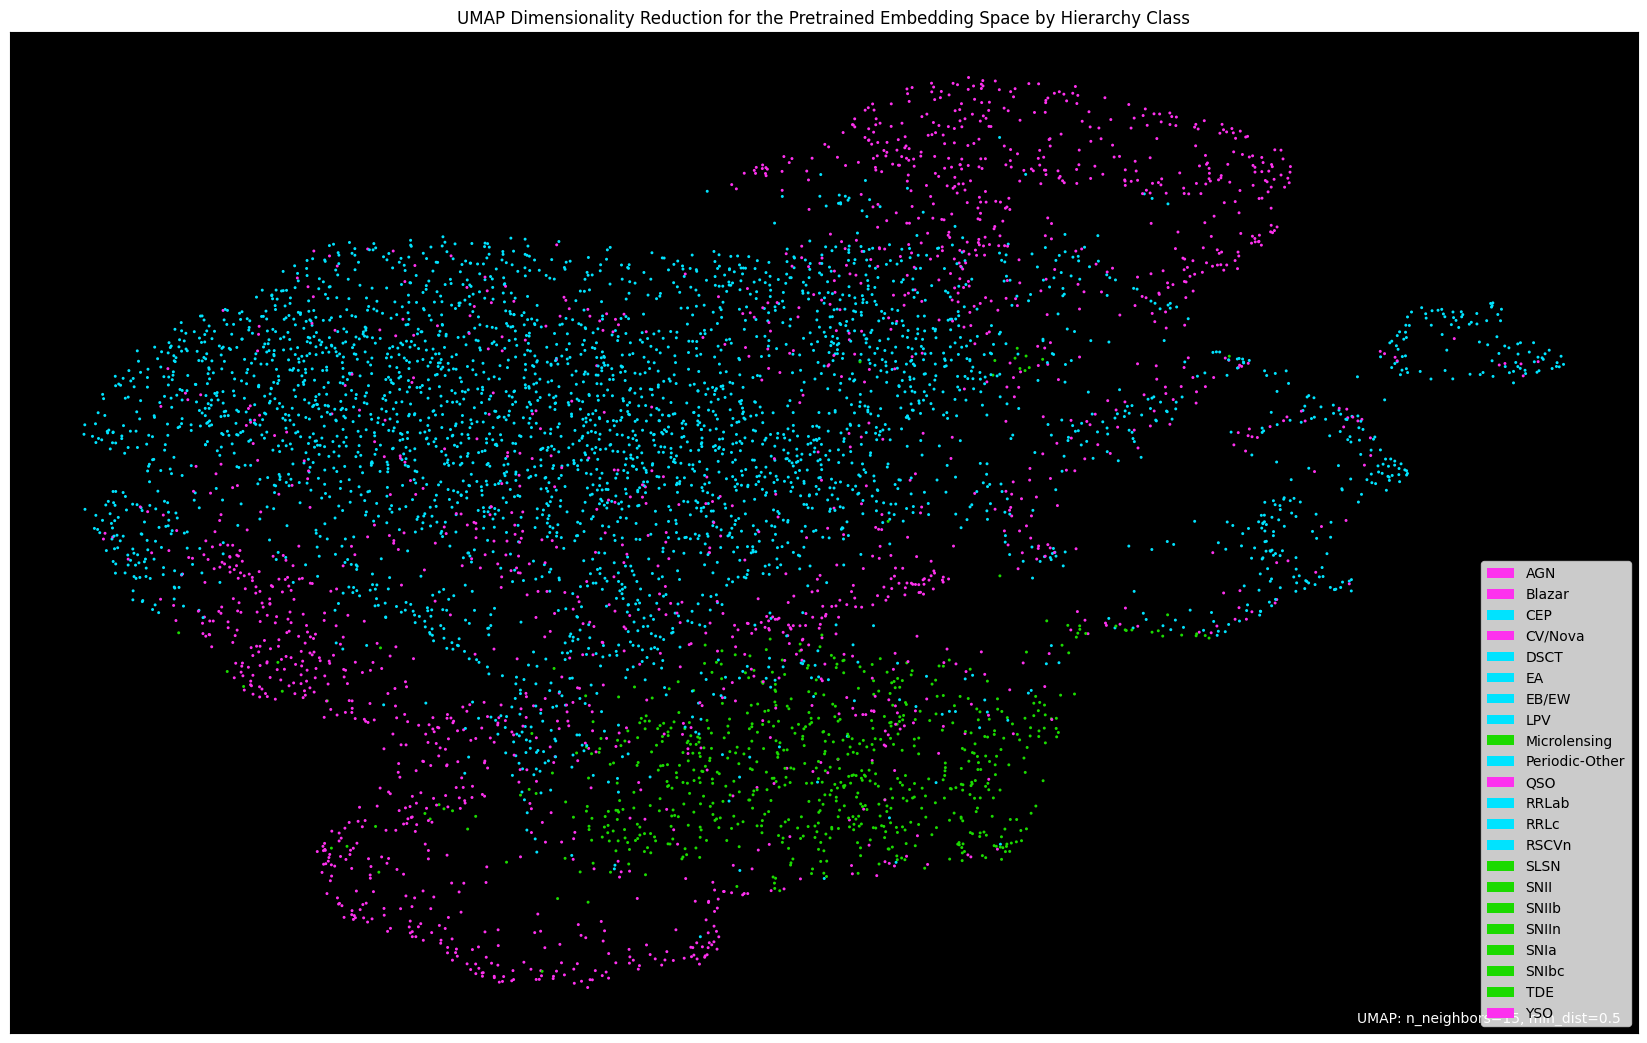

In [89]:

colors_hier = [
    '#fd31ee',# agn
    '#fd31ee', #qso 1

    '#00e3ff', # EA 2

    '#fd31ee', #yso 3

    '#00e3ff', # EA 2
     '#00e3ff',# 6 rrlc
     '#00e3ff',# 6 rrlc
     '#00e3ff',# 6 rrlc
    '#1bda00', # snii 9
    '#00e3ff',# 6 rrlc  tt

    '#fd31ee', # cvnova 5

    '#00e3ff',  # 7 rscvn
    '#00e3ff',  # 7 rscvn
    '#00e3ff',  # 7 rscvn

'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9

'#1bda00', # snii 9
 '#fd31ee', # cvnova 5

    ]
fig = plt.figure(figsize = (21,13))
ax = fig.add_subplot(111)
plt.title('UMAP Dimensionality Reduction for the Pretrained Embedding Space by Hierarchy Class')
umap.plot.points(mapper, labels = np.array([{value:key for key, value in ZTF_TAXONOMY().items()}[i] for i in target.astype(int)]), height = 1080, width = 1920, background = 'black', color_key = colors_hier, ax = ax)


In [90]:
colors = [
    '#ffacfa',# agn
    '#D747CF', #qso 1
    "#189a95", # EA 2

    "#bb3e00", #yso 3
    '#70df00',  # snia 4
    "#FE0912", # cvnova 5

    '#009cff',# 6 rrlc  tt
    "#0004ffff",  # 7 rscvn
    "#cd0066",#'#96034A', #blacar 8

    '#2F8B04', # snii 9
    '#7a71f8', # ebew 10
    "#3b3ee7ff", #lpv 11

    "#41708f", # cep 12
    '#00e3ff', # rrlab 13
    '#1FA9FF', # periodic other 14
     '#00e3ff', #dsct 15
    "#458a00", # snibc 16
    "#1E5A2E", # slsn 17
    "#ff8000", # tde 18

    '#FFC71F', # sniib 19
    '#FFEC1F', # sniin 20
    "#FFFFFF", # microlensing 21
    ]
umap.plot.output_notebook()
p = umap.plot.interactive(mapper,
    labels=target,
    hover_data=hover_data,
    point_size=5,
    tools=["pan","wheel_zoom",
    "box_zoom","save",
    "reset","box_select"],
    width=1920,
    height=1080,
    #theme = 'fire',
    #color_key = colors_hier,
    color_key = colors,
    background = 'black', #midnightblue',
    alpha = 0.9)
umap.plot.show(p)

Loading BokehJS ...